# Rule-Based Career Recommendation System

This notebook implements a career recommendation system using **Rule-Based Scoring** with weighted matching logic.

## Step 1: Import Required Libraries

In [1]:
import json
import pandas as pd
import numpy as np

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 2: Load Career Dataset

In [2]:
# Load careers dataset
with open("careers_dataset_50plus.json", "r") as f:
    careers_data = json.load(f)

print(f"✅ Loaded {len(careers_data)} careers from dataset")
print(f"\nSample career: {careers_data[0]['career_name']}")

✅ Loaded 60 careers from dataset

Sample career: Data Scientist


## Step 3: Prepare Career Data

In [3]:
def safe_list_to_string(data):
    """Convert list or string to clean string format"""
    if isinstance(data, list):
        return " ".join([str(item) for item in data if item])
    elif isinstance(data, str):
        return data
    else:
        return ""

def safe_to_list(data):
    """Convert data to list format"""
    if isinstance(data, list):
        return [str(item).lower() for item in data if item]
    elif isinstance(data, str):
        return [data.lower()]
    else:
        return []

# Create DataFrame
careers_df = pd.DataFrame(careers_data)

# Normalize career data for rule-based matching
for idx, career in enumerate(careers_data):
    careers_data[idx]['required_skills_normalized'] = safe_to_list(career.get('required_skills', []))
    careers_data[idx]['category_normalized'] = str(career.get('category', '')).lower()
    careers_data[idx]['courses_text'] = safe_list_to_string(career.get('recommended_courses', [])).lower()
    careers_data[idx]['roadmap_text'] = str(career.get('roadmap', '')).lower()

print(f"✅ Prepared {len(careers_data)} career profiles for rule-based matching")

✅ Prepared 60 career profiles for rule-based matching


## Step 4: Define Rule-Based Scoring Function

In [4]:
def calculate_rule_score(user_profile, career):
    """
    Calculate rule-based score for a career based on user profile
    
    Scoring Rules:
    - Department/Category match: +10 points
    - Each matching skill: +3 points
    - Each matching certification in courses: +2 points
    - Interest keyword in roadmap/category: +2 points per keyword
    - Project relevance: +1 point per matching project keyword
    
    Args:
        user_profile (dict): User's profile
        career (dict): Career information
    
    Returns:
        int: Total score for the career
    """
    score = 0
    match_details = []
    
    # 1. Department/Category Match (Strong weight)
    user_dept = user_profile.get('department', '').lower()
    career_category = career.get('category_normalized', '')
    
    if user_dept and user_dept in career_category:
        score += 10
        match_details.append(f"Department match: {user_dept}")
    
    # 2. Skills Match
    user_skills = [s.lower() for s in user_profile.get('skills', [])]
    required_skills = career.get('required_skills_normalized', [])
    
    skill_matches = 0
    for user_skill in user_skills:
        for req_skill in required_skills:
            if user_skill in req_skill or req_skill in user_skill:
                score += 3
                skill_matches += 1
                break
    
    if skill_matches > 0:
        match_details.append(f"Skill matches: {skill_matches}")
    
    # 3. Certifications Match
    user_certs = [c.lower() for c in user_profile.get('certifications', [])]
    courses_text = career.get('courses_text', '')
    
    cert_matches = 0
    for cert in user_certs:
        if cert in courses_text:
            score += 2
            cert_matches += 1
    
    if cert_matches > 0:
        match_details.append(f"Certification matches: {cert_matches}")
    
    # 4. Interest Keywords Match
    interests = user_profile.get('interests', '').lower()
    roadmap_text = career.get('roadmap_text', '')
    
    if interests:
        interest_words = [w.strip() for w in interests.split(',') if w.strip()]
        interest_matches = 0
        
        for word in interest_words:
            if word in career_category or word in roadmap_text:
                score += 2
                interest_matches += 1
        
        if interest_matches > 0:
            match_details.append(f"Interest matches: {interest_matches}")
    
    # 5. Project Relevance
    user_projects = [p.lower() for p in user_profile.get('projects', [])]
    project_matches = 0
    
    for project in user_projects:
        project_words = project.split()
        for word in project_words:
            if len(word) > 3 and (word in career_category or word in roadmap_text):
                score += 1
                project_matches += 1
                break
    
    if project_matches > 0:
        match_details.append(f"Project matches: {project_matches}")
    
    return score, match_details

print("✅ Rule-based scoring function defined")

✅ Rule-based scoring function defined


## Step 5: Define Recommendation Function

In [5]:
def recommend_careers_rule_based(user_profile, top_k=5):
    """
    Recommend careers based on user profile using Rule-Based Scoring
    
    Args:
        user_profile (dict): User's profile containing skills, interests, etc.
        top_k (int): Number of recommendations to return
    
    Returns:
        list: Top K recommended careers with scores
    """
    print(f"\n🔍 Analyzing user profile...\n")
    
    # Calculate scores for all careers
    scored_careers = []
    
    for career in careers_data:
        score, match_details = calculate_rule_score(user_profile, career)
        
        scored_careers.append({
            'career_name': career['career_name'],
            'category': career.get('category', 'N/A'),
            'score': score,
            'match_details': match_details,
            'required_skills': career.get('required_skills', []),
            'recommended_courses': career.get('recommended_courses', []),
            'roadmap': career.get('roadmap', 'N/A')
        })
    
    # Sort by score (descending) and get top K
    scored_careers.sort(key=lambda x: x['score'], reverse=True)
    top_recommendations = scored_careers[:top_k]
    
    return top_recommendations

print("✅ Recommendation function defined")

✅ Recommendation function defined


## Step 6: Get User Input

In [6]:
# Collect user input
print("\n" + "="*60)
print("     WELCOME TO RULE-BASED CAREER RECOMMENDER SYSTEM")
print("="*60 + "\n")

name = input("Enter your name: ").strip()
department = input("Enter your department (e.g., CSE, ECE, MECH): ").strip()
skills_input = input("Enter your skills (comma-separated): ").strip()
interests = input("Enter your career interests: ").strip()
projects_input = input("Enter your projects (comma-separated): ").strip()
certifications_input = input("Enter your certifications (comma-separated): ").strip()

# Parse inputs
skills = [s.strip() for s in skills_input.split(',') if s.strip()]
projects = [p.strip() for p in projects_input.split(',') if p.strip()]
certifications = [c.strip() for c in certifications_input.split(',') if c.strip()]

# Create user profile
user_profile = {
    'name': name,
    'department': department,
    'skills': skills,
    'interests': interests,
    'projects': projects,
    'certifications': certifications
}

print("\n✅ Profile created successfully!")


     WELCOME TO RULE-BASED CAREER RECOMMENDER SYSTEM


✅ Profile created successfully!

✅ Profile created successfully!


## Step 7: Generate Recommendations

In [7]:
# Get recommendations
print("\n" + "="*60)
print(f"  CAREER RECOMMENDATIONS FOR {user_profile['name'].upper()}")
print("="*60)

recommendations = recommend_careers_rule_based(user_profile, top_k=5)

# Display recommendations
print(f"\n🎯 Top 5 Career Recommendations (Rule-Based Method):\n")

for i, rec in enumerate(recommendations, 1):
    print(f"\n{'='*60}")
    print(f"Rank #{i}: {rec['career_name']}")
    print(f"{'='*60}")
    print(f"📊 Rule-Based Score: {rec['score']} points")
    print(f"📁 Category: {rec['category']}")
    
    if rec['match_details']:
        print(f"\n🔍 Match Breakdown:")
        for detail in rec['match_details']:
            print(f"   • {detail}")
    
    print(f"\n💡 Required Skills:")
    skills_to_show = rec['required_skills'][:5] if isinstance(rec['required_skills'], list) else []
    for skill in skills_to_show:
        print(f"   • {skill}")
    
    print(f"\n📚 Recommended Courses:")
    courses_to_show = rec['recommended_courses'][:3] if isinstance(rec['recommended_courses'], list) else []
    for course in courses_to_show:
        print(f"   • {course}")
    
    print(f"\n🗺️ Career Roadmap:")
    roadmap = str(rec['roadmap'])
    print(f"   {roadmap[:150]}..." if len(roadmap) > 150 else f"   {roadmap}")

print("\n" + "="*60)
print("           RECOMMENDATIONS COMPLETE!")
print("="*60)


  CAREER RECOMMENDATIONS FOR 

🔍 Analyzing user profile...


🎯 Top 5 Career Recommendations (Rule-Based Method):


Rank #1: Data Scientist
📊 Rule-Based Score: 0 points
📁 Category: Artificial Intelligence

💡 Required Skills:
   • Python
   • Machine Learning
   • Statistics
   • SQL
   • Pandas

📚 Recommended Courses:
   • Machine Learning by Andrew Ng (Coursera)
   • IBM Data Science Professional Certificate (Coursera)
   • NPTEL: Applied Data Science with Python

🗺️ Career Roadmap:
   Start with Python and statistics → Learn data preprocessing and visualization → Master machine learning → Work on real-world projects → Learn MLOps an...

Rank #2: Software Engineer
📊 Rule-Based Score: 0 points
📁 Category: Computer Science

💡 Required Skills:
   • Python
   • Java
   • C++
   • Data Structures
   • Algorithms

📚 Recommended Courses:
   • CS50: Introduction to Computer Science (edX)
   • Data Structures and Algorithms Specialization (Coursera)
   • NPTEL: Programming in Java

🗺️ Career R

## Step 8: Visualize Results (Optional)

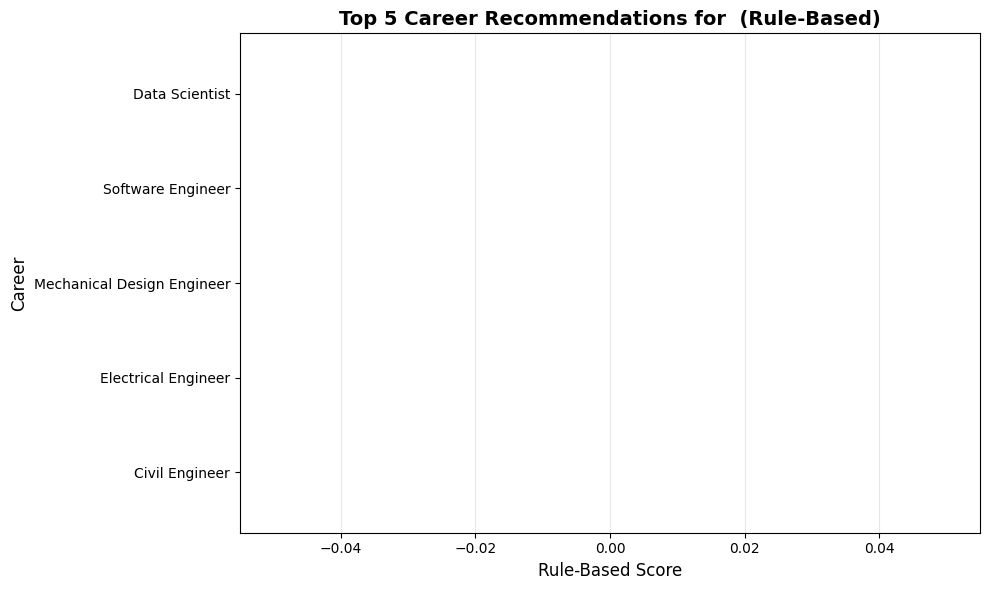

✅ Visualization complete!


In [8]:
import matplotlib.pyplot as plt

# Extract data for visualization
career_names = [rec['career_name'] for rec in recommendations]
scores = [rec['score'] for rec in recommendations]

# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(career_names, scores, color='mediumseagreen')
plt.xlabel('Rule-Based Score', fontsize=12)
plt.ylabel('Career', fontsize=12)
plt.title(f'Top 5 Career Recommendations for {user_profile["name"]} (Rule-Based)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

## Step 9: Score Distribution Analysis (Optional)

In [ ]:
# Analyze score distribution across all careers
all_scores = []
for career in careers_data:
    score, _ = calculate_rule_score(user_profile, career)
    all_scores.append(score)

# Create histogram
plt.figure(figsize=(10, 5))
plt.hist(all_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Careers', fontsize=12)
plt.title('Score Distribution Across All Careers', fontsize=14, fontweight='bold')
plt.axvline(scores[0], color='red', linestyle='--', linewidth=2, label=f'Top Match: {scores[0]}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Score Statistics:")
print(f"   Mean Score: {np.mean(all_scores):.2f}")
print(f"   Median Score: {np.median(all_scores):.2f}")
print(f"   Max Score: {np.max(all_scores):.2f}")
print(f"   Min Score: {np.min(all_scores):.2f}")